<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%205/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
np.random.randint(9999,99999)

12934

12934

Randint:

[0 0 0 ... 0 1 0]


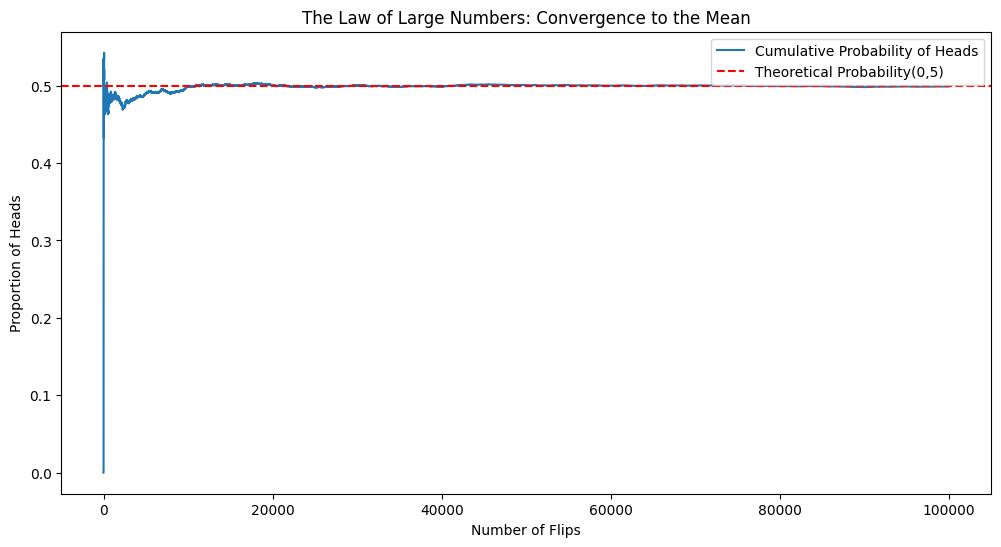

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_law_of_large_numbers(n_flips):
 if n_flips>1:
  flips=np.random.randint(0,2,size=n_flips)

  cumulative_averages=np.cumsum(flips)/np.arange(1,n_flips+1)

  print(flips)

  plt.figure(figsize=(12,6))
  plt.plot(cumulative_averages, label='Cumulative Probability of Heads')
  plt.axhline(0.5, color='red', linestyle='--', label='Theoretical Probability(0,5)')
  plt.title('The Law of Large Numbers: Convergence to the Mean')
  plt.xlabel('Number of Flips')
  plt.ylabel('Proportion of Heads')
  plt.legend()
  plt.show()
 else:
  print("Enter the number of flip greater than 1!")

simulate_law_of_large_numbers(100000)


In-Class Choice Example:

[1 0 1 ... 0 0 1]


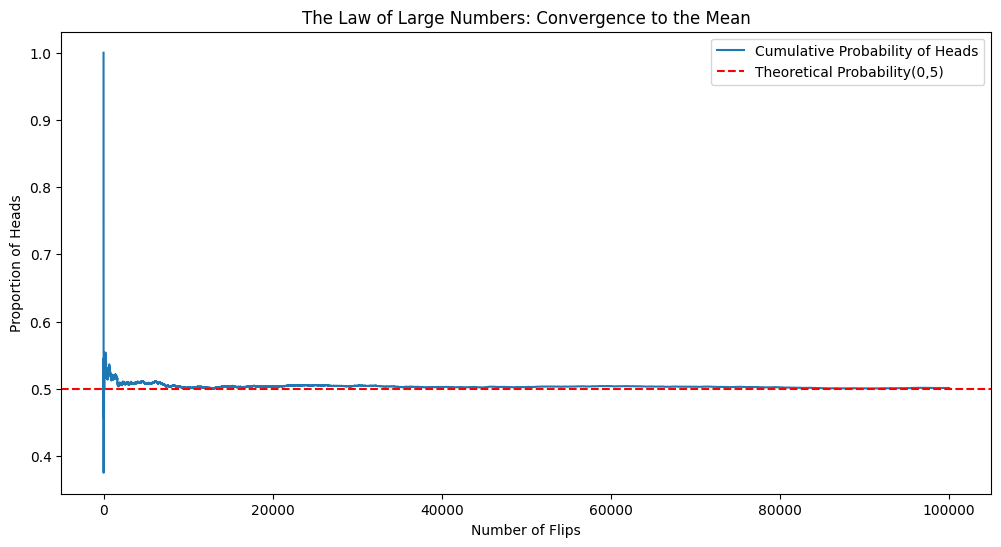

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_law_of_large_numbers(n_flips):
 if n_flips>1:
  flips=np.random.choice([0,1],size=n_flips, p=[0.5,0.5])

  cumulative_averages=np.cumsum(flips)/np.arange(1,n_flips+1)

  print(flips)

  plt.figure(figsize=(12,6))
  plt.plot(cumulative_averages, label='Cumulative Probability of Heads')
  plt.axhline(0.5, color='red', linestyle='--', label='Theoretical Probability(0,5)')
  plt.title('The Law of Large Numbers: Convergence to the Mean')
  plt.xlabel('Number of Flips')
  plt.ylabel('Proportion of Heads')
  plt.legend()
  plt.show()
 else:
  print("Enter the number of flip greater than 1!")

simulate_law_of_large_numbers(100000)


In [ ]:
def monty_hall_sim(n_games):
  switch_wins=0
  stay_wins=0

  for _ in range(n_games):
    doors=[0,1,2]
    prize=np.random.choice(doors)
    choice = np.random.choice(doors)

    openable_doors = [d for d in doors if d !=prize and d != choice]
    host_opens = np.random.choice(openable_doors)

    if choice == prize:
      stay_wins += 1

      switch_choice = [d for d in doors if d != choice and d != host_opens]
      if switch_choice[0] == prize:
        switch_wins += 1

  print(f"Win Rate (Stay): {stay_wins/n_games:.2%}")
  print(f"Win Rate (Switch): {switch_wins/n_games:.2%}")

monty_hall_sim(10000)

Win Rate (Stay): 33.88%
Win Rate (Switch): 0.00%


Probability of Revenue Decline: 100.00%
95% Value at Risk (Worst Case): $5,627,605.67


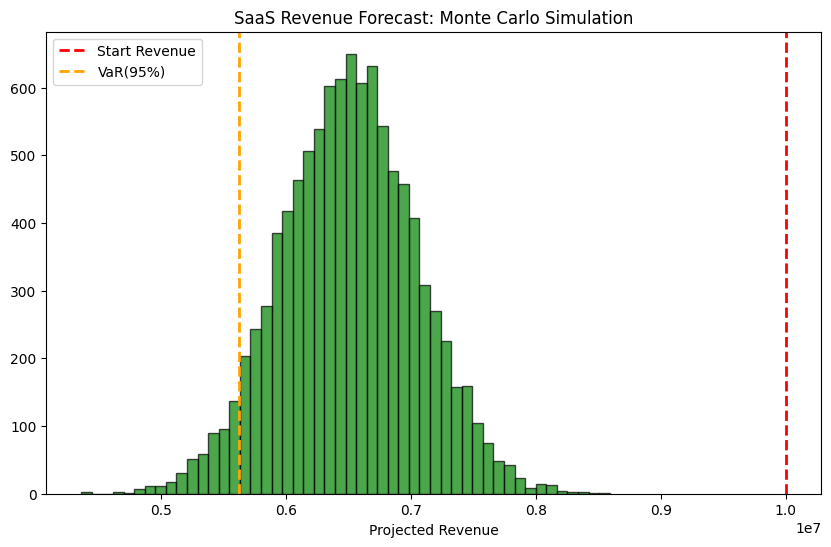

In [ ]:
def saas_risk_model(n_sims):
  base_rev = 10_000_000
  churn_sims = np.random.normal(0.50, 0.02, n_sims)
  sales_sims = np.random.normal(1_500_000, 500_000, n_sims)
  net_revenue = base_rev * (1-churn_sims)+sales_sims
  prob_loss = np.mean(net_revenue<base_rev)
  var_95 = np.percentile(net_revenue, 5)

  print(f"Probability of Revenue Decline: {prob_loss:.2%}")
  print(f"95% Value at Risk (Worst Case): ${var_95:,.2f}")

  plt.figure(figsize=(10,6))
  plt.hist(net_revenue, bins=50, alpha=0.7, color='green', edgecolor='black')
  plt.axvline(base_rev,color='red', linestyle='dashed', linewidth=2, label='Start Revenue')
  plt.axvline(var_95, color='orange', linestyle='dashed', linewidth=2, label='VaR(95%)')
  plt.title('SaaS Revenue Forecast: Monte Carlo Simulation')
  plt.xlabel('Projected Revenue')
  plt.legend()
  plt.show()

saas_risk_model(10000)


Probability of Revenue Decline: 17.82%
95% Value at Risk (Worst Case): $9,612,276.17


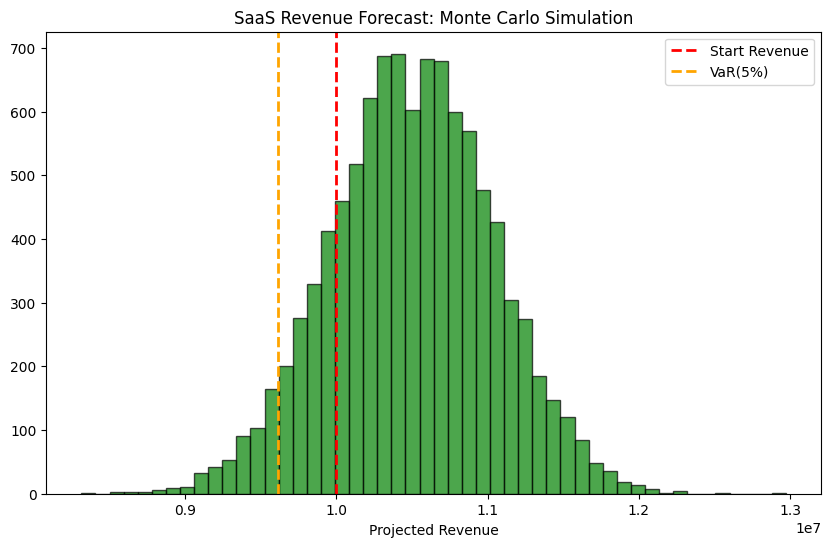

Probability of Revenue Decline: 21.24%
95% Value at Risk (Worst Case): $9,242,049.65


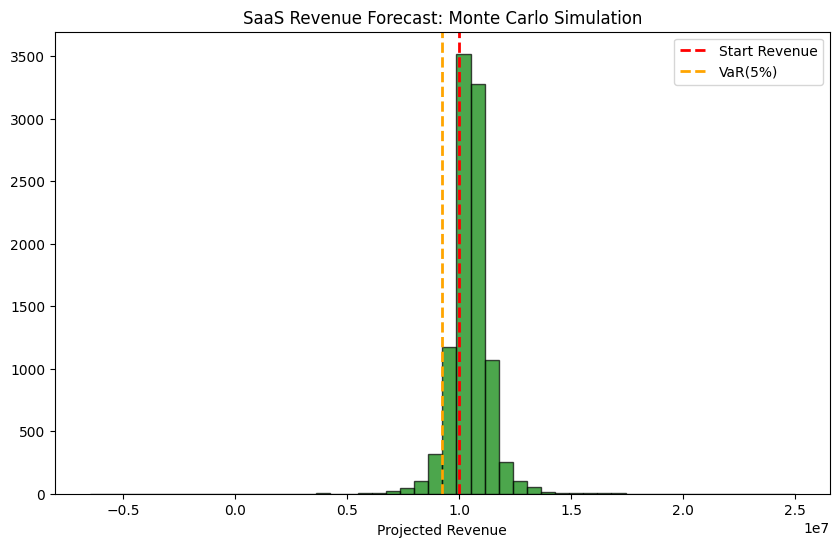


--- VaR Comparison (5th percentile) ---
Normal Var: $9,612,276.17
Fat Tail Var: $9,242,049.65


In [ ]:
def saas_risk_model(n_sims, fat_tail=False, df=3):
  base_rev = 10_000_000
  churn_sims = np.random.normal(0.10, 0.02, n_sims)

  mu_sales = 1_500_000
  sigma_sales = 500_000

  if not fat_tail:
     sales_sims = np.random.normal(mu_sales, sigma_sales, n_sims)
     model_name = 'Normal'
  else:
    t_raw = np.random.standard_t(df=df, size=n_sims)
    sales_sims = mu_sales + sigma_sales*t_raw
    model_name = f"Fat Tail (t, df={df})"

  net_revenue = base_rev * (1-churn_sims)+sales_sims
  prob_loss = np.mean(net_revenue<base_rev)
  var_05 = np.percentile(net_revenue, 5)

  print(f"Probability of Revenue Decline: {prob_loss:.2%}")
  print(f"95% Value at Risk (Worst Case): ${var_05:,.2f}")

  plt.figure(figsize=(10,6))
  plt.hist(net_revenue, bins=50, alpha=0.7, color='green', edgecolor='black')
  plt.axvline(base_rev,color='red', linestyle='dashed', linewidth=2, label='Start Revenue')
  plt.axvline(var_05, color='orange', linestyle='dashed', linewidth=2, label='VaR(5%)')
  plt.title('SaaS Revenue Forecast: Monte Carlo Simulation')
  plt.xlabel('Projected Revenue')
  plt.legend()
  plt.show()

  return var_05

var_normal = saas_risk_model(10000, fat_tail=False)
var_fat = saas_risk_model(10000, fat_tail=True, df=3)

print("\n--- VaR Comparison (5th percentile) ---")
print(f"Normal Var: ${var_normal:,.2f}")
print(f"Fat Tail Var: ${var_fat:,.2f}")


Ans: There is a $370,227 difference between 95% Var distribution and t distribution when df is 3. Based on the result, the probability is also impacted, which caused an increase in the probability of income-decrease. To be specific, a 3.42% increase from  17.82% to 21.24% in the Fat-tail situation model. The key reason for this scene is due to the underestimation. In detail, the underestimation of the "extremes" existence probability. For instance, looking at the graph, fattail modle has a wider distribution range compared to the normal distribution, also it has negative values. Therefore, it is important to considering the use of fattail model to prepare the encounter of extreme conditions, such as the recent slump in crypto market.